# The escalated case: the note to Meera

**Week 1, Thursday. The afternoon's escalated case, 60 minutes, alone.** Five parts, twelve lettered
choices, and a note of under 200 words at the end. The brief is
`exercises/unguided/C2_W01_D04_escalated_case_STUDENT.md`.

> **The client asks.** "One page, two minutes. If the honest answer is 'we do not know yet', say so and
> tell me what would tell us." Meera Raghavan, CEO, Kalpa Retail

Each `__TODOn__` is a choice between the four lines in the comment above it: replace the placeholder
with the line you choose, run the cell, and read the check below it. Run All stops at the first
placeholder with a NameError until you replace it; that is expected. Post the twelve letters in order
at the end.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")
EXPOSURE = kit.load_csv("C2_W01_D04_exposure_STUDENT.csv")
CAMPAIGNS = kit.load_csv("C2_W01_D04_campaigns_STUDENT.csv")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Student", "Business"]


def mean(values):
    return sum(values) / len(values)


def shuffle_gaps(q1, q2, times, seed):
    random.seed(seed)
    pool = q1 + q2
    gaps = []
    for _ in range(times):
        random.shuffle(pool)
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def flip_rises(n_orders, times, seed):
    random.seed(seed)
    rises = []
    for _ in range(times):
        q2 = sum(1 for _ in range(n_orders) if random.random() < 0.5)
        q1 = n_orders - q2
        rises.append(float("inf") if q1 == 0 else q2 / q1 - 1)
    return rises


print(len(ORDERS), "orders,", len(EXPOSURE), "customers in the exposure table,", len(CAMPAIGNS), "campaign")

186 orders, 160 customers in the exposure table, 1 campaign


## Part 1. Real? Retail-Plus, 5,000 shuffles

Delivered revenue per member, Q1 against Q2, shuffled 5,000 times with seed 2026.

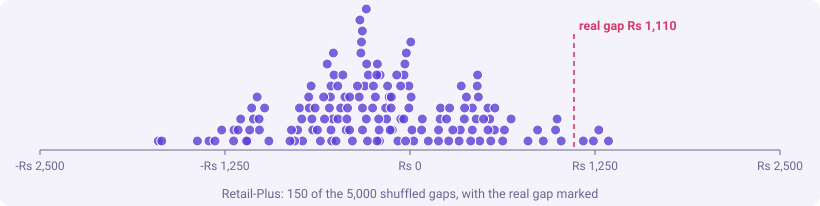

real gap Rs 1,110 per member; share 0.027


In [2]:
def member_totals(segment, quarter):
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        # TODO 1. Which orders count as money Kalpa kept?
        #   a) o["status"] != "cancelled"
        #   b) o["status"] == "delivered"
        #   c) o["amount"] != ""
        #   d) o["status"] in ("delivered", "returned")
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


plus_q1, plus_q2 = member_totals("Retail-Plus", "Q1"), member_totals("Retail-Plus", "Q2")
plus_gap = mean(plus_q1) - mean(plus_q2)
gaps = shuffle_gaps(plus_q1, plus_q2, 5000, seed=2026)
# TODO 2. Which share is the p-value for a fall at least as large as the real one?
#   a) sum(1 for g in gaps if g <= plus_gap) / len(gaps)
#   b) sum(1 for g in gaps if g >= 0) / len(gaps)
#   c) sum(1 for g in gaps if g >= plus_gap) / len(gaps)
#   d) sum(1 for g in gaps if abs(g) >= abs(plus_gap)) / len(gaps)
plus_share = sum(1 for g in gaps if g >= plus_gap) / len(gaps)
kit.strip(gaps[:150], markers=[("real gap", plus_gap, "bad")], lo=-2500, hi=2500,
          title="Retail-Plus: 150 of the 5,000 shuffled gaps, with the real gap marked")
print(f"real gap Rs {plus_gap:,.0f} per member; share {plus_share:.3f}")

**TODO 1 is b.** Monday settled that delivered is the money kept. a keeps returned orders, whose money went back; c keeps every order, including cancelled ones; d counts returns as sales.

**TODO 2 is c.** A fall at least as large as the real one is a shuffled gap at or above the real gap. a counts the smaller gaps, the opposite tail; b counts every shuffle that fell at all; d counts rises as well as falls, which is the two-direction share and about twice the one Meera asked for.

In [3]:
# TODO 3. Which sentence survives Kavya's review?
#   a) "If nothing had changed, a fall this large turns up in about 3 of 100 shuffles."
#   b) "p = 0.03, so there is a 3 percent chance the drop is not real."
#   c) "p = 0.03, so the drop is 97 percent certain and large."
#   d) "The shuffle proves the Retail-Plus drop is real, so it is now the biggest problem for Monday."
sentence = "If nothing had changed, a fall this large turns up in about 3 of 100 shuffles."
print(sentence)
kit.check("the real gap is Rs 1,110 per member", round(plus_gap) == 1110, f"{plus_gap:,.1f}")
kit.check("the share is 0.027 with seed 2026", round(plus_share, 3) == 0.027, f"{plus_share:.4f}")
kit.check("the sentence names the chance-only world", sentence.startswith("If nothing had changed"))

If nothing had changed, a fall this large turns up in about 3 of 100 shuffles.


**TODO 3 is a.** It names the share and the world it was counted in. b and c are the day's first trap, the share read as the chance of being wrong; d is the second, real read as biggest.

## Part 2. Worth it? The fall against the company's quarter

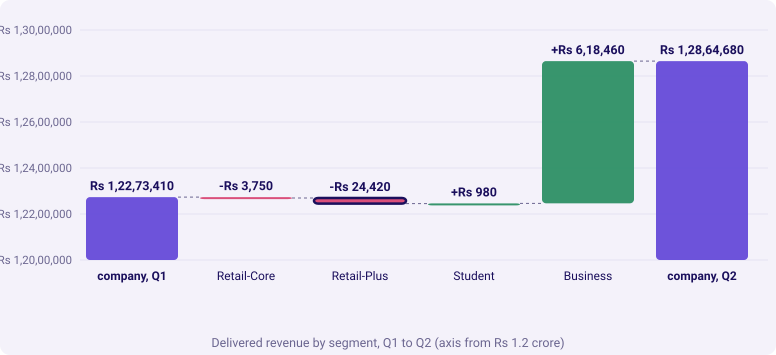

In [4]:
def delivered(segment, quarter):
    return sum(int(o["amount"]) for o in ORDERS
               if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered")


company_q1 = sum(delivered(s, "Q1") for s in SEGMENTS)
company_q2 = sum(delivered(s, "Q2") for s in SEGMENTS)
# TODO 4. What is the segment's fall in rupees a quarter?
#   a) plus_gap
#   b) plus_gap / len(plus_q1)
#   c) plus_gap * len(plus_q1)
#   d) sum(plus_q1) - plus_gap * 100
plus_fall = plus_gap * len(plus_q1)
# TODO 5. What is the fall measured against, for Meera?
#   a) sum(plus_q1)
#   b) company_q2
#   c) len(ORDERS)
#   d) delivered("Business", "Q2")
share_of_company = plus_fall / company_q2
kit.bridge(("company, Q1", company_q1), [(s, delivered(s, "Q2") - delivered(s, "Q1")) for s in SEGMENTS],
           end_label="company, Q2", lo=12_000_000, lit=[1], title="Delivered revenue by segment, Q1 to Q2 (axis from Rs 1.2 crore)")
kit.check("the fall is Rs 24,420 a quarter", round(plus_fall) == 24420, kit.rupees(round(plus_fall)))
kit.check("it is under half of one percent of the company's Q2", share_of_company < 0.005, f"{share_of_company:.2%}")

**TODO 4 is c.** A per-member gap times the members who exist in both quarters is the segment's fall. a is still per member; b divides again; d mixes a total with a gap.

**TODO 5 is b.** Meera runs the company, so the fall is set against the company's quarter. a sizes it against the segment, which is the head of Retail-Plus's view; c is a count of orders; d leaves out every other segment.

## Part 3. Student: the rate with its count

The count is yours to find; nothing below prints it.

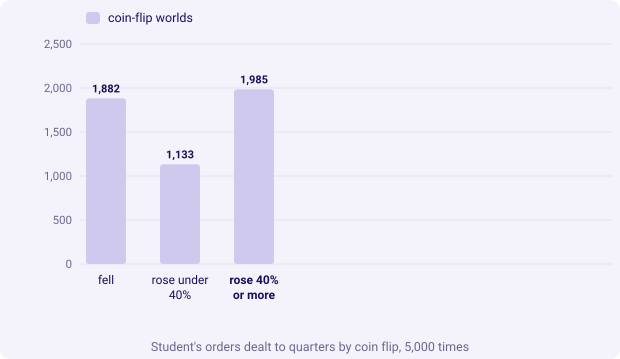

In [5]:
def orders_in(segment, quarter):
    return sum(1 for o in ORDERS if o["segment"] == segment and o["quarter"] == quarter)


index_student = round(100 * orders_in("Student", "Q2") / orders_in("Student", "Q1"))
# TODO 6. What count stands behind Student's 40 percent?
#   a) sum(1 for o in ORDERS if o["segment"] == "Student")
#   b) orders_in("Student", "Q2") - orders_in("Student", "Q1") + 100
#   c) len(ORDERS)
#   d) index_student
student_n = sum(1 for o in ORDERS if o["segment"] == "Student")
# TODO 7. Which chance reference fits a count of orders?
#   a) flip_rises(400, 5000, seed=2026)
#   b) shuffle_gaps(plus_q1, plus_q2, 5000, seed=2026)
#   c) [0.4] * 5000
#   d) flip_rises(student_n, 5000, seed=2026)
rises = flip_rises(student_n, 5000, seed=2026)
student_share = sum(1 for r in rises if r >= 0.4 - 1e-9) / len(rises)
kit.columns(["fell", "rose under 40%", "rose 40% or more"],
            [("coin-flip worlds", [sum(1 for r in rises if r < 0), sum(1 for r in rises if 0 <= r < 0.4 - 1e-9),
                                   sum(1 for r in rises if r >= 0.4 - 1e-9)])],
            lit=[2], width=620, title="Student's orders dealt to quarters by coin flip, 5,000 times")
kit.check("Student's orders rose 40 percent", index_student == 140)
kit.check("the count behind the rate is under thirty", student_n < 30)
kit.check("chance makes a 40 percent rise in more than a third of worlds", student_share > 0.33, f"{student_share:.3f}")

**TODO 6 is a.** The count behind a rate is the number of observations it stands on. b is a change plus an index; c counts every segment; d is the rate itself.

**TODO 7 is d.** A coin flip per order on Student's own count is the chance reference for a count. a is the invented 400; b is round one's shuffle on another segment; c assumes the answer.

## Part 4. The discount: did it work, and for whom?

The exposure table holds one row per customer in the campaign's comparison: the segment, whether the
customer got the monsoon sale, and August revenue.

blended: exposed Rs 3,395 against Rs 3,200, +6.1%


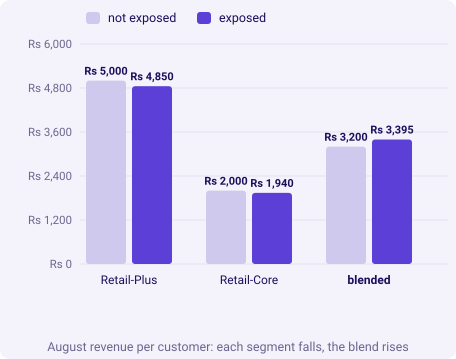

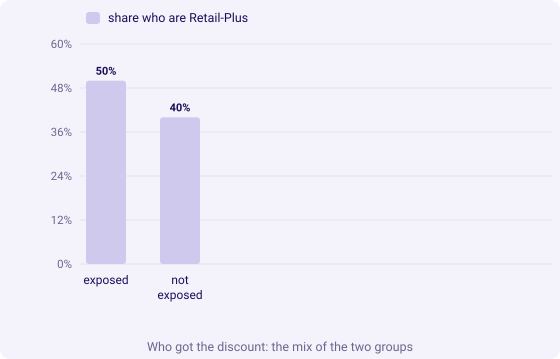

In [6]:
# TODO 8. Which rows are the customers who got the discount?
#   a) r["campaign_id"] == ""
#   b) r["exposed"] == "yes"
#   c) r["segment"] == "Retail-Plus"
#   d) r["august_revenue"] != ""
exposed = [r for r in EXPOSURE if r["exposed"] == "yes"]
others = [r for r in EXPOSURE if r not in exposed]
blend_yes = mean([int(r["august_revenue"]) for r in exposed])
blend_no = mean([int(r["august_revenue"]) for r in others])
blend_lift = blend_yes / blend_no - 1
print(f"blended: exposed {kit.rupees(blend_yes)} against {kit.rupees(blend_no)}, {blend_lift:+.1%}")


def avg(segment, flag):
    return mean([int(r["august_revenue"]) for r in EXPOSURE if r["segment"] == segment and r["exposed"] == flag])


def count(flag, segment=None):
    return sum(1 for r in EXPOSURE if r["exposed"] == flag and (segment is None or r["segment"] == segment))


# TODO 9. Where does the fair comparison run?
#   a) ["Retail-Plus", "Retail-Core"]
#   b) ["yes", "no"]
#   c) ["Retail-Plus"]
#   d) ["Retail-Plus", "Retail-Core", "blended"]
within = {s: avg(s, "yes") / avg(s, "no") - 1 for s in ["Retail-Plus", "Retail-Core"]}
# TODO 10. What share of the exposed customers are Retail-Plus members?
#   a) count("yes", "Retail-Plus") / len(EXPOSURE)
#   b) count("no", "Retail-Plus") / count("no")
#   c) count("yes") / len(EXPOSURE)
#   d) count("yes", "Retail-Plus") / count("yes")
plus_mix_exposed = count("yes", "Retail-Plus") / count("yes")
plus_mix_others = count("no", "Retail-Plus") / count("no")
kit.columns(["Retail-Plus", "Retail-Core", "blended"],
            [("not exposed", [avg("Retail-Plus", "no"), avg("Retail-Core", "no"), round(blend_no)]),
             ("exposed", [avg("Retail-Plus", "yes"), avg("Retail-Core", "yes"), round(blend_yes)])],
            fmt=kit.rupees, lit=[2], title="August revenue per customer: each segment falls, the blend rises")
kit.columns(["exposed", "not exposed"], [("share who are Retail-Plus", [round(100 * plus_mix_exposed), round(100 * plus_mix_others)])],
            fmt=lambda v: f"{v:.0f}%", width=560, title="Who got the discount: the mix of the two groups")
kit.check("the blend rises about 6 percent", 0.05 < blend_lift < 0.07, f"{blend_lift:+.1%}")
kit.check("inside every segment the exposed spent less", all(v < 0 for v in within.values()), f"{within}")
kit.check("the exposed group leans more to Retail-Plus", plus_mix_exposed > plus_mix_others,
          f"{plus_mix_exposed:.0%} against {plus_mix_others:.0%}")

**TODO 8 is b.** The exposure flag records who got the discount. a picks the customers with no campaign, the opposite group; c picks a segment; d picks everyone.

**TODO 9 is a.** The fair comparison runs inside each segment. b are the two groups, which is the blend again; c leaves out Retail-Core; d puts the blend back in as if it were a segment.

**TODO 10 is d.** Retail-Plus members over all exposed customers is the mix of the exposed group. a divides by every customer in the table; b is the unexposed group's mix; c is the exposed share of the table.

## Part 5. The note

Pick the caveat and the action, then write the note in the markdown cell below: claim, evidence,
caveat, action, for all three of Meera's questions, under 200 words.

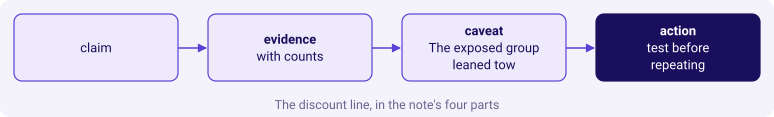

In [7]:
# TODO 11. Which caveat goes in the note?
#   a) "The shuffle proves the discount failed in both segments."
#   b) "There are no caveats, since both tables come from marketing's own system and they agree with each other."
#   c) "Revenue data is never fully reliable."
#   d) "The exposed group leaned toward Retail-Plus, who spend more anyway, so the blend mixes the two."
caveat = "The exposed group leaned toward Retail-Plus, who spend more anyway, so the blend mixes the two."
# TODO 12. Which action goes in the note?
#   a) "Repeat the sale for Diwali, since the blended figure rose about 6 percent across all exposed customers."
#   b) "End every discount programme from Monday."
#   c) "Do not repeat it as designed; hold back a random slice of each segment at Diwali."
#   d) "No view until more data arrives."
action = "Do not repeat it as designed; hold back a random slice of each segment at Diwali."
kit.flow(["claim", "evidence\nwith counts", "caveat\n" + caveat.split(",")[0][:28], "action\ntest before repeating"],
         lit=3, title="The discount line, in the note's four parts")
kit.check("the caveat names who got the discount", "leaned toward Retail-Plus" in caveat)
kit.check("the action tests before it repeats", "hold back" in action)

**TODO 11 is d.** The caveat names who got the discount and why that moves the blend. a overclaims from a test that was never run on this table; b is not a caveat; c is true of everything and changes nothing.

**TODO 12 is c.** A position with the test that would settle it. a is the trap; b overclaims the other way; d gives Meera nothing to act on.

**A model note, 150 words.**

**Claim.** Retail-Plus really is spending less, and it is small against the company; Student is too
thin to fund yet; the monsoon sale did not work as designed.

**Evidence.** Retail-Plus members delivered Rs 1,110 less each in Q2; chance makes a fall that large in
about 3 of 100 shuffles. It is Rs 24,420 a quarter, 0.19 percent of delivered revenue. Student's 40
percent rise stands on under thirty orders, and coin flips make it in four worlds of ten. The sale's
6 percent is a blend: inside Retail-Plus and Retail-Core, exposed customers spent 3 percent less.

**Caveat.** The sale went mostly to Retail-Plus, who spend more anyway, and the exposure table gives
one August figure per group, so we cannot see the spread.

**Action.** Test a retention offer on half of Retail-Plus; watch Student until thirty orders a quarter;
do not repeat the sale as designed, and hold back a random slice of each segment at Diwali.

In [8]:
note = """Retail-Plus really is spending less, and it is small against the company; Student is too thin to
fund yet; the monsoon sale did not work as designed. Retail-Plus members delivered Rs 1,110 less each in
Q2; chance makes a fall that large in about 3 of 100 shuffles. It is Rs 24,420 a quarter, 0.19 percent
of delivered revenue. Student's 40 percent rise stands on under thirty orders, and coin flips make it in
four worlds of ten. The sale's 6 percent is a blend: inside Retail-Plus and Retail-Core, exposed
customers spent 3 percent less. The sale went mostly to Retail-Plus, who spend more anyway, and the
exposure table gives one August figure per group, so we cannot see the spread. Test a retention offer on
half of Retail-Plus; watch Student until thirty orders a quarter; do not repeat the sale as designed, and
hold back a random slice of each segment at Diwali."""
words = len(note.split())
print(words, "words")
kit.check("the note is under 200 words", words < 200, f"{words}")
kit.check("the note gives each question a line", all(k in note for k in ("Retail-Plus", "Student", "sale")))
kit.check_summary()
print("Post the twelve letters in order, then read your note aloud to your partner.")

154 words


Post the twelve letters in order, then read your note aloud to your partner.
